# Lake

## Deterministic

Loaded 12 archive(s) across 12 cells
No seed dimension in folder names — plotting single values without error bars.
Saved ./lake_figures/hv_policy_form.png
Saved ./lake_figures/archive_size_and_runtime.png


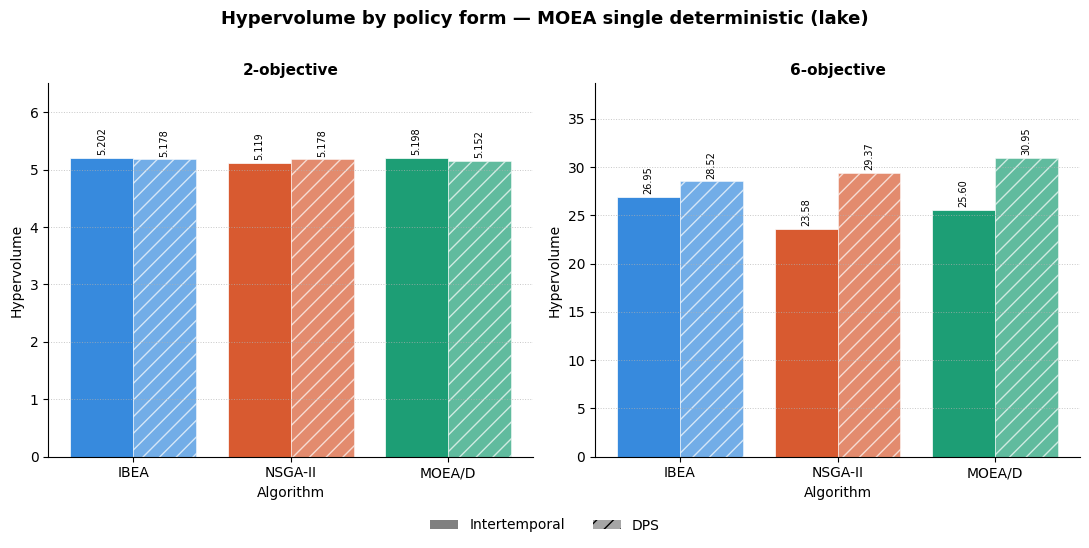

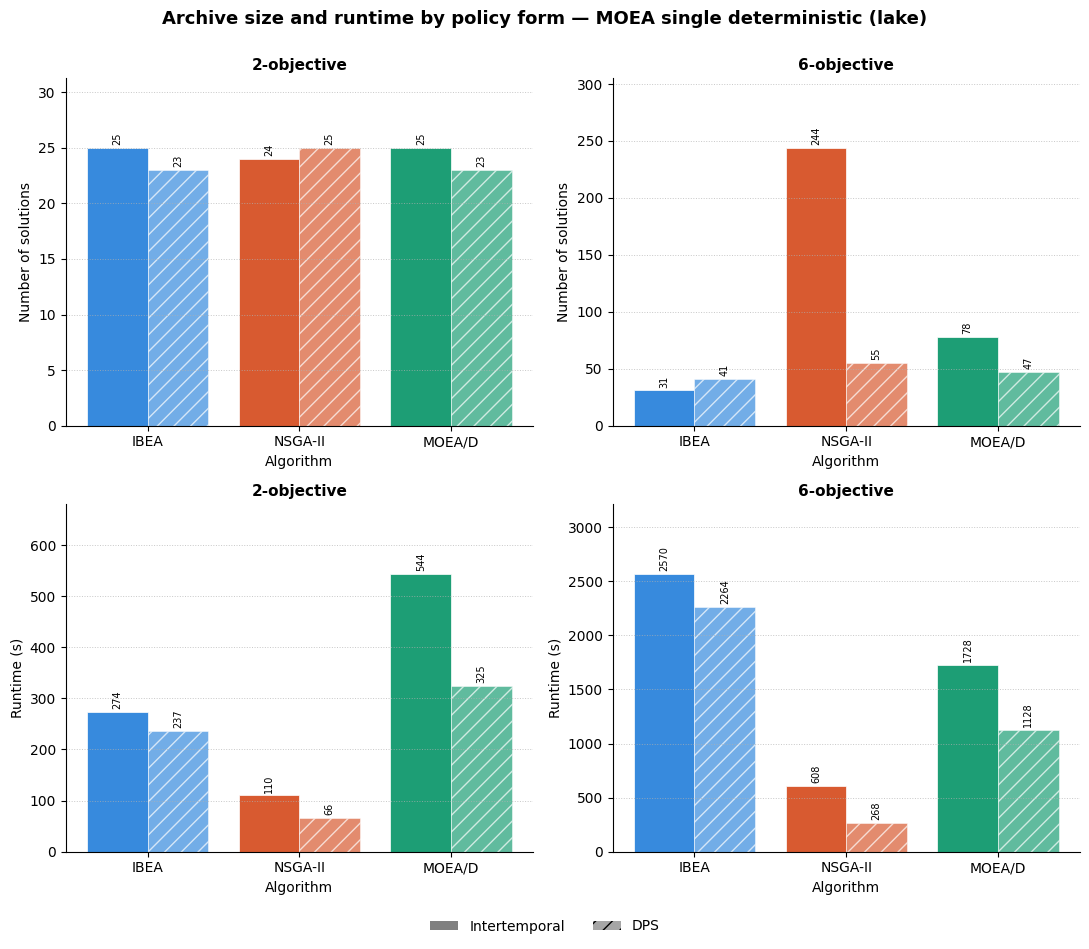

In [6]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

POLICY_LABEL = {
    "intertemporal": "Intertemporal",
    "dps":           "DPS",
}

ALGOS    = ["IBEA", "NSGAII", "MOEAD"]
POLICIES = ["intertemporal", "dps"]
N_OBJS   = [2, 6]

FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_single_(\d+)(?:_seed(\d+))?$'
)


def _archive_csv(folder_path):
    files = os.listdir(folder_path)
    archives = sorted(f for f in files
                      if f.startswith('archives_') and f.endswith('.csv'))
    return archives[0] if archives else None


def _compute_hv(df, ref_value=-1.1):
    obj_cols = [c for c in df.columns if c.startswith('o')]
    if not obj_cols:
        return None, 0
    vals = -df[obj_cols].values
    if len(vals) == 0:
        return 0.0, 0
    ref = np.full(len(obj_cols), ref_value)
    return hypervolume(ref, [tuple(r) for r in vals]), len(vals)


def _parse_runtime_seconds(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergences_') and f.endswith('.csv'))
    if not convs:
        return None
    df = pd.read_csv(os.path.join(folder_path, convs[0]))
    if 'time' not in df.columns or len(df) == 0:
        return None
    last = str(df['time'].iloc[-1])
    try:
        h, m, s = map(int, last.split(':'))
        return h * 3600 + m * 60 + s
    except (ValueError, AttributeError):
        return None


def load_dataset(base, ref_value=-1.1):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        policy, algo, n_obj, seed = m.groups()
        n_obj = int(n_obj)
        seed = int(seed) if seed is not None else None
        folder_path = os.path.join(base, d)
        csv_name = _archive_csv(folder_path)
        if csv_name is None:
            continue
        df = pd.read_csv(os.path.join(folder_path, csv_name))
        hv, n_points = _compute_hv(df, ref_value=ref_value)
        if hv is None:
            continue
        runtime_s = _parse_runtime_seconds(folder_path)
        records.append({
            'policy': policy, 'algo': algo,
            'n_obj': n_obj, 'seed': seed,
            'hv': hv, 'n_points': n_points,
            'runtime_s': runtime_s,
        })
    return pd.DataFrame(records)


def aggregate(df):
    grouped = df.groupby(['policy', 'algo', 'n_obj']).agg(
        hv_mean=('hv', 'mean'),
        hv_std=('hv', 'std'),
        n_seeds=('hv', 'count'),
        n_points_mean=('n_points', 'mean'),
        n_points_std=('n_points', 'std'),
        runtime_mean=('runtime_s', 'mean'),
        runtime_std=('runtime_s', 'std'),
    ).reset_index()
    grouped['hv_std'] = grouped['hv_std'].fillna(0.0)
    grouped['n_points_std'] = grouped['n_points_std'].fillna(0.0)
    grouped['runtime_std'] = grouped['runtime_std'].fillna(0.0)
    return grouped


def plot_bars(ax, agg, n_obj, title, metric='hv'):
    subset = agg[agg['n_obj'] == n_obj]
    x = np.arange(len(ALGOS))
    width = 0.4
    offsets = [-width / 2, width / 2]

    has_variance = (subset['n_seeds'] > 1).any()

    if metric == 'hv':
        mean_col, std_col, ylabel = 'hv_mean', 'hv_std', 'Hypervolume'
        label_fmt = lambda v: f'{v:#.4g}'
    elif metric == 'n_points':
        mean_col, std_col, ylabel = 'n_points_mean', 'n_points_std', 'Number of solutions'
        label_fmt = lambda v: f'{v:.0f}'
    elif metric == 'runtime':
        mean_col, std_col, ylabel = 'runtime_mean', 'runtime_std', 'Runtime (s)'
        label_fmt = lambda v: f'{v:.0f}'
    else:
        raise ValueError(
            f"metric must be 'hv', 'n_points', or 'runtime'; got {metric!r}"
        )

    for offset, policy in zip(offsets, POLICIES):
        means = []
        stds = []
        for algo in ALGOS:
            row = subset[(subset['algo'] == algo) & (subset['policy'] == policy)]
            if len(row) == 0:
                means.append(0.0)
                stds.append(0.0)
            else:
                means.append(float(row[mean_col].iloc[0]))
                stds.append(float(row[std_col].iloc[0]))

        alpha = 1.0 if policy == 'intertemporal' else 0.7
        hatch = '' if policy == 'intertemporal' else '//'

        bars = ax.bar(
            x + offset, means, width=width,
            yerr=stds if has_variance else None,
            capsize=3 if has_variance else 0,
            label=POLICY_LABEL[policy],
            color=[ALGO_COLORS[a] for a in ALGOS],
            alpha=alpha,
            edgecolor='white', linewidth=0.5,
            hatch=hatch,
            error_kw={'ecolor': '0.3', 'linewidth': 0.8} if has_variance else {},
        )
        ax.bar_label(
            bars,
            labels=[label_fmt(v) for v in means],
            padding=2, fontsize=7, rotation=90,
        )

    max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
    ax.set_ylim(0, max_val * 1.25)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


if __name__ == '__main__':
    BASE = './lake_data/moea_deterministic'
    OUT = './lake_figures'
    REF_VALUE = -1.1

    os.makedirs(OUT, exist_ok=True)

    raw = load_dataset(BASE, ref_value=REF_VALUE)
    if raw.empty:
        raise SystemExit(f'No data found under {BASE}')

    has_seed = raw['seed'].notna().any()
    n_cells = len(raw[['policy', 'algo', 'n_obj']].drop_duplicates())
    print(f'Loaded {len(raw)} archive(s) across {n_cells} cells')
    if has_seed:
        n_seeds_seen = raw[raw['seed'].notna()].groupby(
            ['policy', 'algo', 'n_obj'])['seed'].nunique()
        print(f'Seeds per cell: min={n_seeds_seen.min()}, max={n_seeds_seen.max()}')
    else:
        print('No seed dimension in folder names — plotting single values without error bars.')

    agg = aggregate(raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle(
        'Hypervolume by policy form — MOEA single deterministic (lake)',
        fontsize=13, fontweight='bold', y=1.01,
    )
    plot_bars(ax1, agg, n_obj=2, title='2-objective', metric='hv')
    plot_bars(ax2, agg, n_obj=6, title='6-objective', metric='hv')

    legend_handles = [
        Patch(facecolor='grey', alpha=1.0, hatch='',   label=POLICY_LABEL['intertemporal']),
        Patch(facecolor='grey', alpha=0.7, hatch='//', label=POLICY_LABEL['dps']),
    ]
    fig.legend(
        handles=legend_handles, loc='lower center', ncol=len(legend_handles),
        bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=10,
    )
    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_policy_form.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

    fig2, axes = plt.subplots(2, 2, figsize=(11, 9))
    fig2.suptitle(
        'Archive size and runtime by policy form — MOEA single deterministic (lake)',
        fontsize=13, fontweight='bold', y=1.00,
    )
    plot_bars(axes[0, 0], agg, n_obj=2, title='2-objective', metric='n_points')
    plot_bars(axes[0, 1], agg, n_obj=6, title='6-objective', metric='n_points')
    plot_bars(axes[1, 0], agg, n_obj=2, title='2-objective', metric='runtime')
    plot_bars(axes[1, 1], agg, n_obj=6, title='6-objective', metric='runtime')

    fig2.legend(
        handles=legend_handles, loc='lower center', ncol=len(legend_handles),
        bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10,
    )
    fig2.tight_layout()
    out_path2 = os.path.join(OUT, 'archive_size_and_runtime.png')
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path2}')

Loaded 12 convergence curve(s) across 12 cells
No seed dimension in folder names — plotting single curves without bands.
Saved ./lake_figures/convergence_epsilon_progress.png


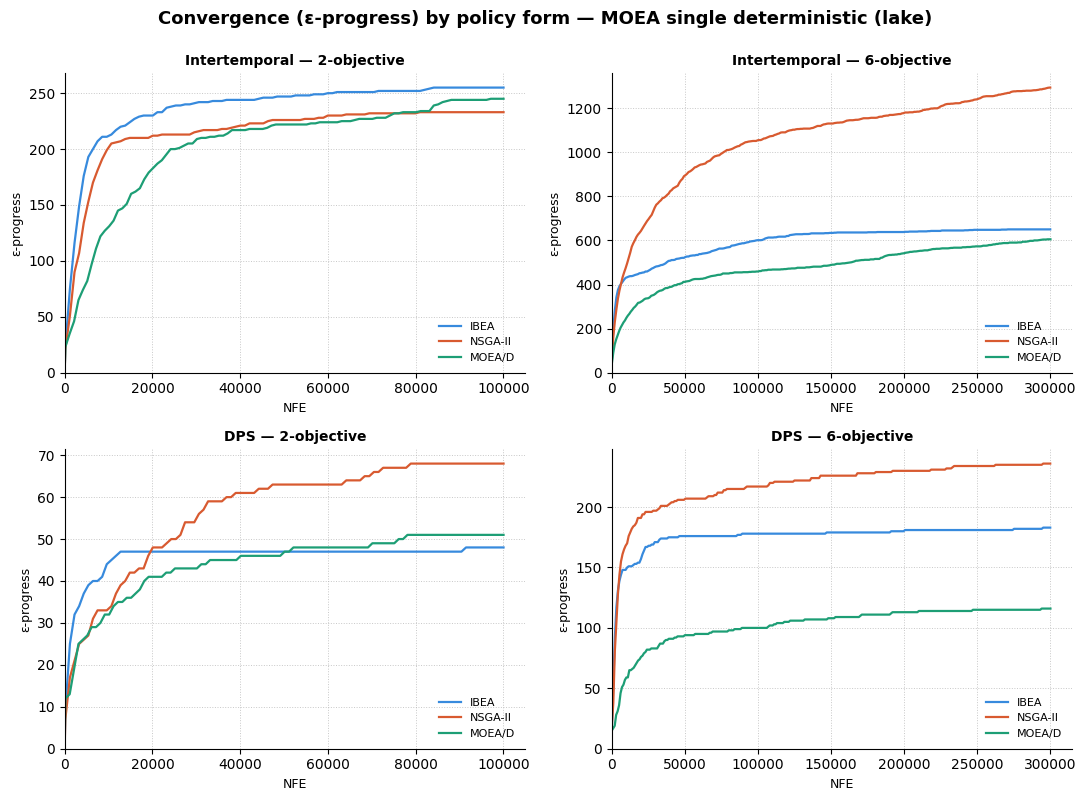

In [7]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

POLICY_LABEL = {
    "intertemporal": "Intertemporal",
    "dps":           "DPS",
}

ALGOS    = ["IBEA", "NSGAII", "MOEAD"]
POLICIES = ["intertemporal", "dps"]
N_OBJS   = [2, 6]

FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_single_(\d+)(?:_seed(\d+))?$'
)


def _convergence_csv(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergences_') and f.endswith('.csv'))
    return convs[0] if convs else None


def load_convergences(base):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        policy, algo, n_obj, seed = m.groups()
        n_obj = int(n_obj)
        seed = int(seed) if seed is not None else None
        folder_path = os.path.join(base, d)
        csv_name = _convergence_csv(folder_path)
        if csv_name is None:
            continue
        df = pd.read_csv(os.path.join(folder_path, csv_name))
        if 'nfe' not in df.columns or 'epsilon_progress' not in df.columns:
            continue
        records.append({
            'policy': policy,
            'algo': algo,
            'n_obj': n_obj,
            'seed': seed,
            'df': df[['nfe', 'epsilon_progress']].copy(),
        })
    return records


def aggregate_curves(records, policy, algo, n_obj, common_grid=None):
    matching = [r for r in records
                if r['policy'] == policy
                and r['algo'] == algo
                and r['n_obj'] == n_obj]
    if not matching:
        return None, None, None

    if len(matching) == 1:
        df = matching[0]['df']
        return df['nfe'].values, df['epsilon_progress'].values, np.zeros(len(df))

    if common_grid is None:
        max_nfe = max(r['df']['nfe'].max() for r in matching)
        common_grid = np.linspace(0, max_nfe, 200)

    interpolated = []
    for r in matching:
        df = r['df']
        y = np.interp(common_grid, df['nfe'].values, df['epsilon_progress'].values)
        interpolated.append(y)
    arr = np.array(interpolated)
    return common_grid, arr.mean(axis=0), arr.std(axis=0)


def plot_convergence_panel(ax, records, policy, n_obj, title):
    has_data = False
    for algo in ALGOS:
        grid, mean, std = aggregate_curves(records, policy, algo, n_obj)
        if grid is None:
            continue
        has_data = True
        color = ALGO_COLORS[algo]
        ax.plot(grid, mean, color=color, linewidth=1.6,
                label=ALGO_LABELS[algo])
        if (std > 0).any():
            ax.fill_between(grid, mean - std, mean + std,
                            color=color, alpha=0.2, linewidth=0)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('NFE', fontsize=9)
    ax.set_ylabel('ε-progress', fontsize=9)
    ax.grid(linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    if has_data:
        ax.legend(fontsize=8, loc='lower right', frameon=False)


if __name__ == '__main__':
    BASE = './lake_data/moea_deterministic'
    OUT = './lake_figures'
    os.makedirs(OUT, exist_ok=True)

    records = load_convergences(BASE)
    if not records:
        raise SystemExit(f'No convergence data found under {BASE}')

    n_cells = len({(r['policy'], r['algo'], r['n_obj']) for r in records})
    print(f'Loaded {len(records)} convergence curve(s) across {n_cells} cells')
    has_seed = any(r['seed'] is not None for r in records)
    if has_seed:
        from collections import Counter
        seeds_per_cell = Counter(
            (r['policy'], r['algo'], r['n_obj']) for r in records
        )
        print(f'Seeds per cell: min={min(seeds_per_cell.values())}, '
              f'max={max(seeds_per_cell.values())}')
    else:
        print('No seed dimension in folder names — plotting single curves without bands.')

    fig, axes = plt.subplots(
        len(POLICIES), len(N_OBJS),
        figsize=(11, 4.0 * len(POLICIES)),
        sharex=False,
    )
    fig.suptitle(
        'Convergence (ε-progress) by policy form — MOEA single deterministic (lake)',
        fontsize=13, fontweight='bold', y=0.995,
    )

    for i, policy in enumerate(POLICIES):
        for j, n_obj in enumerate(N_OBJS):
            ax = axes[i, j]
            title = f'{POLICY_LABEL[policy]} — {n_obj}-objective'
            plot_convergence_panel(ax, records, policy, n_obj, title)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'convergence_epsilon_progress.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

## Deterministic (MORL)

Computing HV for 6 cells using 6 worker(s)...
  done in 1049.4s
Loaded 6 archive(s) across 6 cells
No seed dimension in folder names — plotting single values without error bars.
Saved ./lake_figures/morl_hv_scoring.png
Saved ./lake_figures/morl_archive_size_and_runtime.png


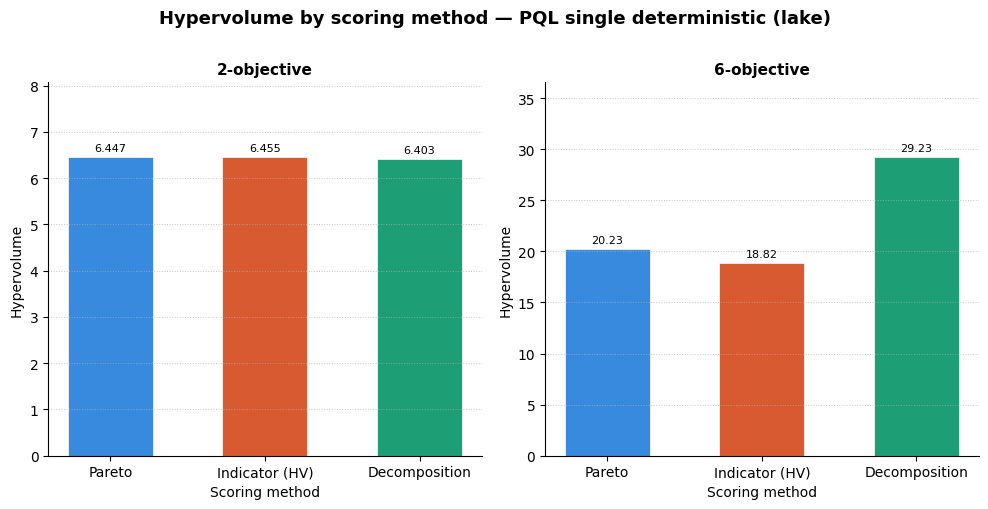

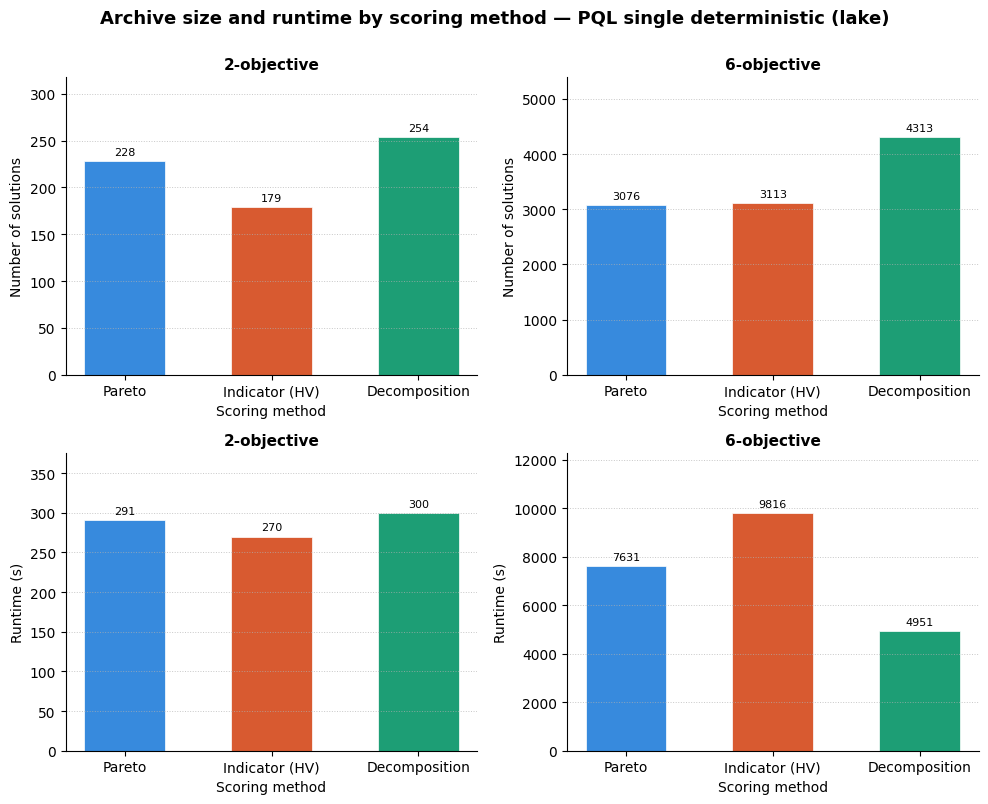

In [4]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed, cpu_count
from moocore import hypervolume as moo_hv

SCORING_LABELS = {
    "pareto":        "Pareto",
    "indicator":     "Indicator (HV)",
    "decomposition": "Decomposition",
}
SCORING_COLORS = {
    "pareto":        "#378ADD",
    "indicator":     "#D85A30",
    "decomposition": "#1D9E75",
}

SCORINGS = ["pareto", "indicator", "decomposition"]
N_OBJS   = [2, 6]

FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_single_(\d+)(?:_seed(\d+))?$'
)


def _pcs_csv(folder_path):
    files = os.listdir(folder_path)
    pcs = sorted(f for f in files if f.startswith('pcs_') and f.endswith('.csv'))
    return pcs[0] if pcs else None


def _convergence_csv(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergence_') and f.endswith('.csv'))
    return convs[0] if convs else None


def _parse_runtime_seconds(folder_path):
    csv_name = _convergence_csv(folder_path)
    if csv_name is None:
        return None
    df = pd.read_csv(os.path.join(folder_path, csv_name))
    if 'time' not in df.columns or len(df) == 0:
        return None
    last = str(df['time'].iloc[-1])
    try:
        h, m, s = map(int, last.split(':'))
        return h * 3600 + m * 60 + s
    except (ValueError, AttributeError):
        return None


def _hv_one_cell(args):
    pcs_path, ref_value = args
    df = pd.read_csv(pcs_path)
    obj_cols = [c for c in df.columns if c.startswith('o')]
    n_obj = len(obj_cols)
    vals = df[obj_cols].values
    if len(vals) == 0:
        return 0.0, 0
    ref = np.full(n_obj, abs(ref_value))
    hv = moo_hv(-vals, ref=ref)
    return float(hv), len(vals)


def load_dataset(base, ref_value=-1.1, n_workers=None):
    cells = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        scoring, n_obj, seed = m.groups()
        n_obj = int(n_obj)
        seed = int(seed) if seed is not None else None
        folder_path = os.path.join(base, d)
        pcs_name = _pcs_csv(folder_path)
        if pcs_name is None:
            continue
        cells.append({
            'scoring': scoring,
            'n_obj': n_obj,
            'seed': seed,
            'folder_path': folder_path,
            'pcs_path': os.path.join(folder_path, pcs_name),
            'runtime_s': _parse_runtime_seconds(folder_path),
        })

    if not cells:
        return pd.DataFrame()

    if n_workers is None:
        n_workers = max(1, cpu_count() - 1)
    n_workers = min(n_workers, len(cells))

    args_list = [(c['pcs_path'], ref_value) for c in cells]
    print(f'Computing HV for {len(cells)} cells using {n_workers} worker(s)...')
    t0 = time.time()
    if n_workers == 1:
        results = [_hv_one_cell(a) for a in args_list]
    else:
        results = Parallel(n_jobs=n_workers)(
            delayed(_hv_one_cell)(a) for a in args_list
        )
    print(f'  done in {time.time() - t0:.1f}s')

    records = []
    for c, (hv, n_points) in zip(cells, results):
        records.append({
            'scoring': c['scoring'],
            'n_obj': c['n_obj'],
            'seed': c['seed'],
            'hv': hv,
            'n_points': n_points,
            'runtime_s': c['runtime_s'],
        })
    return pd.DataFrame(records)


def aggregate(df):
    grouped = df.groupby(['scoring', 'n_obj']).agg(
        hv_mean=('hv', 'mean'),
        hv_std=('hv', 'std'),
        n_seeds=('hv', 'count'),
        n_points_mean=('n_points', 'mean'),
        n_points_std=('n_points', 'std'),
        runtime_mean=('runtime_s', 'mean'),
        runtime_std=('runtime_s', 'std'),
    ).reset_index()
    grouped['hv_std'] = grouped['hv_std'].fillna(0.0)
    grouped['n_points_std'] = grouped['n_points_std'].fillna(0.0)
    grouped['runtime_std'] = grouped['runtime_std'].fillna(0.0)
    return grouped


def plot_bars(ax, agg, n_obj, title, metric='hv'):
    subset = agg[agg['n_obj'] == n_obj]
    x = np.arange(len(SCORINGS))
    width = 0.55

    has_variance = (subset['n_seeds'] > 1).any()

    if metric == 'hv':
        mean_col, std_col, ylabel = 'hv_mean', 'hv_std', 'Hypervolume'
        label_fmt = lambda v: f'{v:#.4g}'
    elif metric == 'n_points':
        mean_col, std_col, ylabel = 'n_points_mean', 'n_points_std', 'Number of solutions'
        label_fmt = lambda v: f'{v:.0f}'
    elif metric == 'runtime':
        mean_col, std_col, ylabel = 'runtime_mean', 'runtime_std', 'Runtime (s)'
        label_fmt = lambda v: f'{v:.0f}'
    else:
        raise ValueError(
            f"metric must be 'hv', 'n_points', or 'runtime'; got {metric!r}"
        )

    means = []
    stds = []
    for s in SCORINGS:
        row = subset[subset['scoring'] == s]
        if len(row) == 0:
            means.append(0.0)
            stds.append(0.0)
        else:
            means.append(float(row[mean_col].iloc[0]))
            stds.append(float(row[std_col].iloc[0]))

    bars = ax.bar(
        x, means, width=width,
        yerr=stds if has_variance else None,
        capsize=3 if has_variance else 0,
        color=[SCORING_COLORS[s] for s in SCORINGS],
        edgecolor='white', linewidth=0.5,
        error_kw={'ecolor': '0.3', 'linewidth': 0.8} if has_variance else {},
    )
    ax.bar_label(
        bars,
        labels=[label_fmt(v) for v in means],
        padding=3, fontsize=8,
    )

    max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
    ax.set_ylim(0, max_val * 1.25)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Scoring method', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([SCORING_LABELS[s] for s in SCORINGS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


if __name__ == '__main__':
    BASE = './lake_data/morl_deterministic'
    OUT = './lake_figures'
    REF_VALUE = -1.1
    N_WORKERS = None

    os.makedirs(OUT, exist_ok=True)

    raw = load_dataset(BASE, ref_value=REF_VALUE, n_workers=N_WORKERS)
    if raw.empty:
        raise SystemExit(f'No data found under {BASE}')

    has_seed = raw['seed'].notna().any()
    n_cells = len(raw[['scoring', 'n_obj']].drop_duplicates())
    print(f'Loaded {len(raw)} archive(s) across {n_cells} cells')
    if has_seed:
        n_seeds_seen = raw[raw['seed'].notna()].groupby(
            ['scoring', 'n_obj'])['seed'].nunique()
        print(f'Seeds per cell: min={n_seeds_seen.min()}, max={n_seeds_seen.max()}')
    else:
        print('No seed dimension in folder names — plotting single values without error bars.')

    agg = aggregate(raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        'Hypervolume by scoring method — PQL single deterministic (lake)',
        fontsize=13, fontweight='bold', y=1.01,
    )
    plot_bars(ax1, agg, n_obj=2, title='2-objective', metric='hv')
    plot_bars(ax2, agg, n_obj=6, title='6-objective', metric='hv')
    fig.tight_layout()
    out_path = os.path.join(OUT, 'morl_hv_scoring.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

    fig2, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig2.suptitle(
        'Archive size and runtime by scoring method — PQL single deterministic (lake)',
        fontsize=13, fontweight='bold', y=1.00,
    )
    plot_bars(axes[0, 0], agg, n_obj=2, title='2-objective', metric='n_points')
    plot_bars(axes[0, 1], agg, n_obj=6, title='6-objective', metric='n_points')
    plot_bars(axes[1, 0], agg, n_obj=2, title='2-objective', metric='runtime')
    plot_bars(axes[1, 1], agg, n_obj=6, title='6-objective', metric='runtime')
    fig2.tight_layout()
    out_path2 = os.path.join(OUT, 'morl_archive_size_and_runtime.png')
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path2}')

Loaded 6 convergence curve(s) across 6 cells
No seed dimension in folder names — plotting single curves without bands.
Saved ./lake_figures/morl_convergence_pcs_size.png


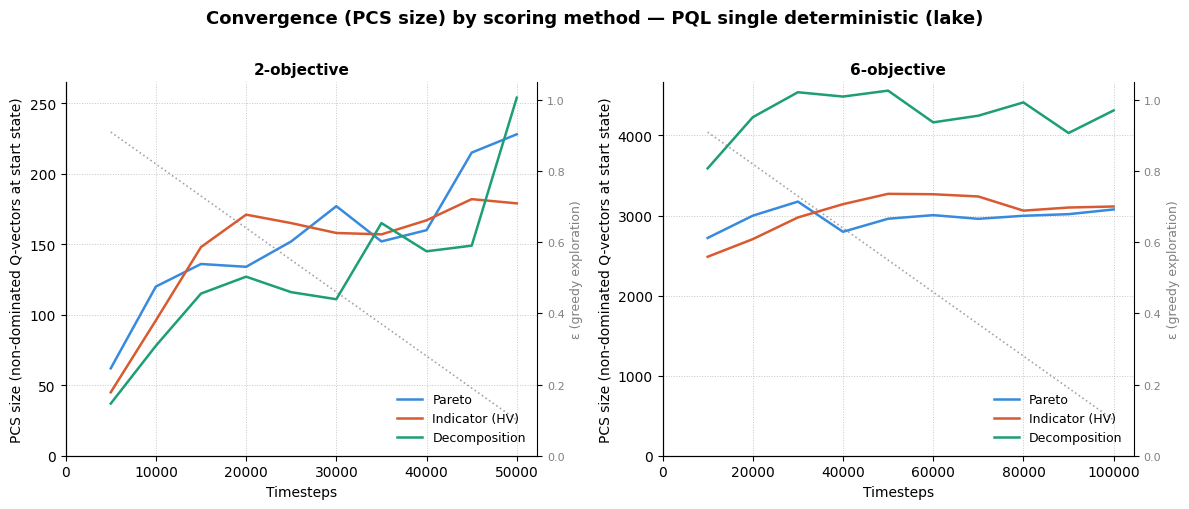

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCORING_LABELS = {
    "pareto":        "Pareto",
    "indicator":     "Indicator (HV)",
    "decomposition": "Decomposition",
}
SCORING_COLORS = {
    "pareto":        "#378ADD",
    "indicator":     "#D85A30",
    "decomposition": "#1D9E75",
}

SCORINGS = ["pareto", "indicator", "decomposition"]
N_OBJS   = [2, 6]

FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_single_(\d+)(?:_seed(\d+))?$'
)


def _convergence_csv(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergence_') and f.endswith('.csv'))
    return convs[0] if convs else None


def load_convergences(base):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        scoring, n_obj, seed = m.groups()
        n_obj = int(n_obj)
        seed = int(seed) if seed is not None else None
        folder_path = os.path.join(base, d)
        csv_name = _convergence_csv(folder_path)
        if csv_name is None:
            continue
        df = pd.read_csv(os.path.join(folder_path, csv_name))
        needed = {'timestep', 'pcs_size', 'epsilon'}
        if not needed.issubset(df.columns):
            continue
        records.append({
            'scoring': scoring,
            'n_obj': n_obj,
            'seed': seed,
            'df': df[['timestep', 'pcs_size', 'epsilon']].copy(),
        })
    return records


def aggregate_curves(records, scoring, n_obj, value_col):
    matching = [r for r in records
                if r['scoring'] == scoring and r['n_obj'] == n_obj]
    if not matching:
        return None, None, None

    if len(matching) == 1:
        df = matching[0]['df']
        return df['timestep'].values, df[value_col].values, np.zeros(len(df))

    max_ts = max(r['df']['timestep'].max() for r in matching)
    common_grid = np.linspace(
        min(r['df']['timestep'].min() for r in matching),
        max_ts, 200,
    )
    interpolated = []
    for r in matching:
        df = r['df']
        y = np.interp(common_grid, df['timestep'].values, df[value_col].values)
        interpolated.append(y)
    arr = np.array(interpolated)
    return common_grid, arr.mean(axis=0), arr.std(axis=0)


def plot_convergence_panel(ax, records, n_obj, title, show_epsilon=True):
    has_data = False
    for scoring in SCORINGS:
        grid, mean, std = aggregate_curves(records, scoring, n_obj, 'pcs_size')
        if grid is None:
            continue
        has_data = True
        color = SCORING_COLORS[scoring]
        ax.plot(grid, mean, color=color, linewidth=1.8,
                label=SCORING_LABELS[scoring])
        if (std > 0).any():
            ax.fill_between(grid, mean - std, mean + std,
                            color=color, alpha=0.2, linewidth=0)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timesteps', fontsize=10)
    ax.set_ylabel('PCS size (non-dominated Q-vectors at start state)', fontsize=10)
    ax.grid(linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    if show_epsilon and has_data:
        for scoring in SCORINGS:
            grid, mean, _ = aggregate_curves(records, scoring, n_obj, 'epsilon')
            if grid is not None:
                ax2 = ax.twinx()
                ax2.plot(grid, mean, color='gray', linestyle=':',
                         linewidth=1.2, alpha=0.7)
                ax2.set_ylabel('ε (greedy exploration)', fontsize=9, color='gray')
                ax2.tick_params(axis='y', labelcolor='gray', labelsize=8)
                ax2.set_ylim(0, 1.05)
                ax2.spines[['top']].set_visible(False)
                break

    if has_data:
        ax.legend(fontsize=9, loc='lower right', frameon=False)


if __name__ == '__main__':
    BASE = './lake_data/morl_deterministic'
    OUT = './lake_figures'
    os.makedirs(OUT, exist_ok=True)

    records = load_convergences(BASE)
    if not records:
        raise SystemExit(f'No convergence data found under {BASE}')

    n_cells = len({(r['scoring'], r['n_obj']) for r in records})
    print(f'Loaded {len(records)} convergence curve(s) across {n_cells} cells')
    has_seed = any(r['seed'] is not None for r in records)
    if has_seed:
        from collections import Counter
        seeds_per_cell = Counter((r['scoring'], r['n_obj']) for r in records)
        print(f'Seeds per cell: min={min(seeds_per_cell.values())}, '
              f'max={max(seeds_per_cell.values())}')
    else:
        print('No seed dimension in folder names — plotting single curves without bands.')

    fig, axes = plt.subplots(1, len(N_OBJS), figsize=(12, 5))
    fig.suptitle(
        'Convergence (PCS size) by scoring method — PQL single deterministic (lake)',
        fontsize=13, fontweight='bold', y=1.01,
    )

    for j, n_obj in enumerate(N_OBJS):
        plot_convergence_panel(axes[j], records, n_obj, title=f'{n_obj}-objective')

    fig.tight_layout()
    out_path = os.path.join(OUT, 'morl_convergence_pcs_size.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

## Robustness

Loaded 24 evaluated archive(s) across 24 cells
Cells (condition, algo, n_obj):
  dps_moro               IBEA    n_obj=2  pts=  11  hv=  4.4719  runtime=  747s
  dps_moro               IBEA    n_obj=6  pts=  12  hv= 23.0624  runtime= 4125s
  dps_multi              IBEA    n_obj=2  pts=  24  hv=  4.6032  runtime= 1298s
  dps_multi              IBEA    n_obj=6  pts=  83  hv= 39.9483  runtime=10198s
  dps_moro               MOEAD   n_obj=2  pts=  10  hv=  4.5125  runtime=  842s
  dps_moro               MOEAD   n_obj=6  pts=  26  hv= 32.2279  runtime= 2793s
  dps_multi              MOEAD   n_obj=2  pts=  13  hv=  4.4559  runtime= 1658s
  dps_multi              MOEAD   n_obj=6  pts=  76  hv= 41.5985  runtime= 5444s
  dps_moro               NSGAII  n_obj=2  pts=  11  hv=  4.4766  runtime=  596s
  dps_moro               NSGAII  n_obj=6  pts=  20  hv= 25.4441  runtime= 2080s
  dps_multi              NSGAII  n_obj=2  pts=  21  hv=  4.5957  runtime=  361s
  dps_multi              NSGAII  n_obj=6 

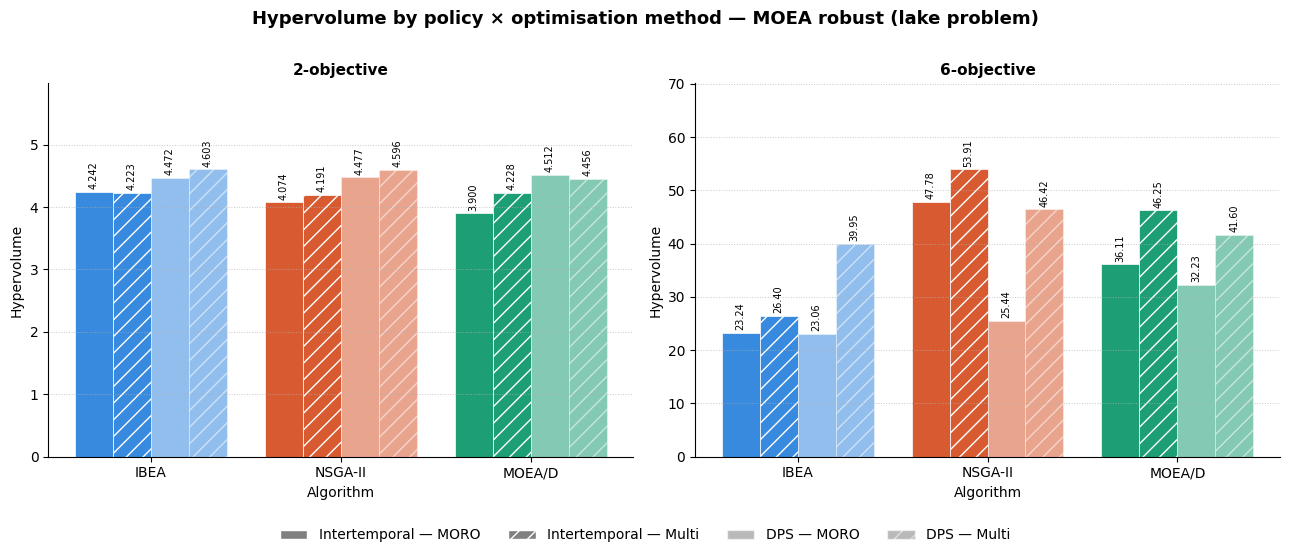

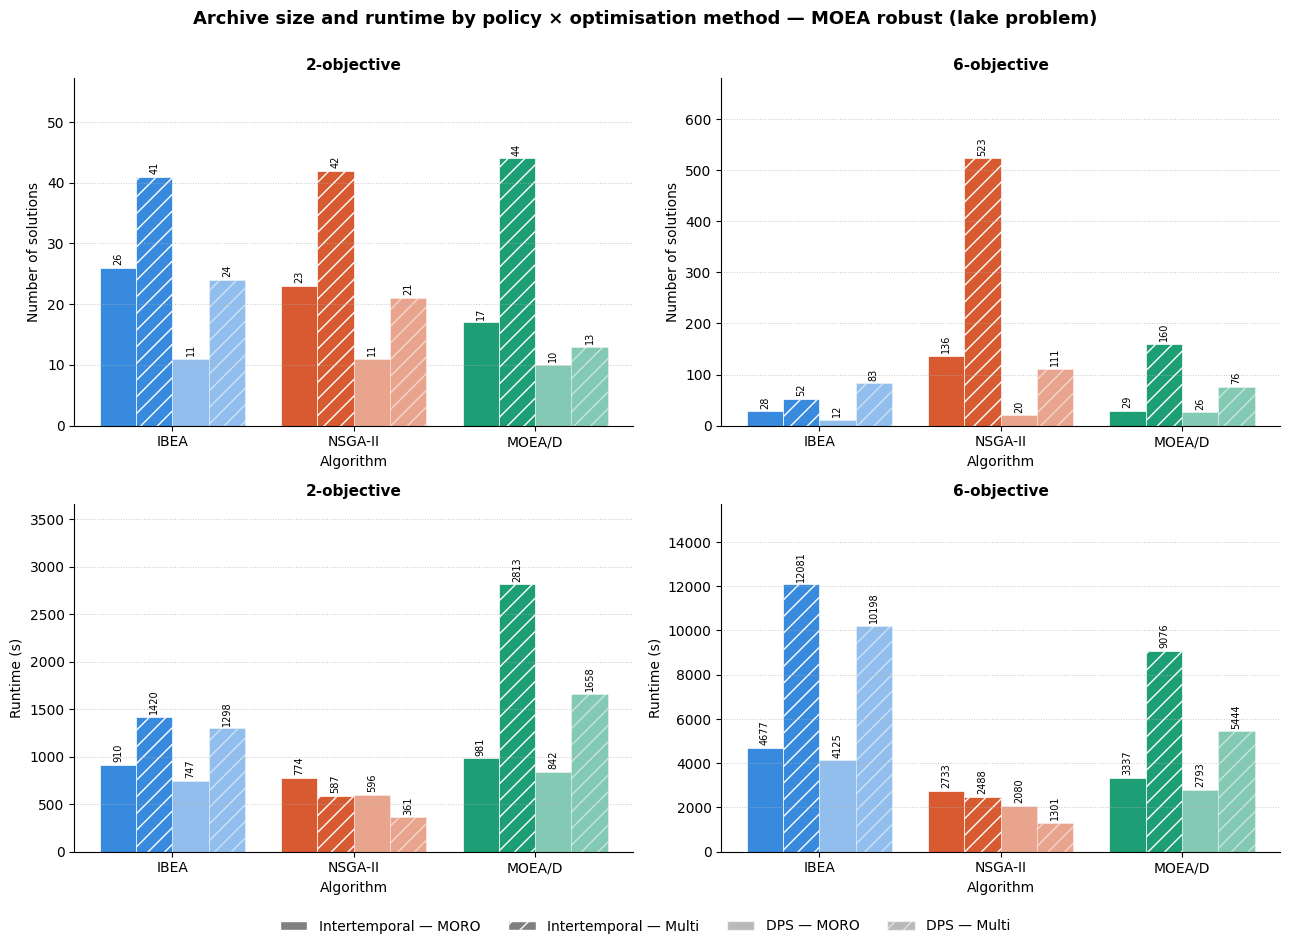

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

COND_LABEL = {
    "intertemporal_moro":  "Intertemporal — MORO",
    "intertemporal_multi": "Intertemporal — Multi",
    "dps_moro":            "DPS — MORO",
    "dps_multi":           "DPS — Multi",
}

COND_ALPHA = {
    "intertemporal_moro":  1.0,
    "intertemporal_multi": 1.0,
    "dps_moro":            0.55,
    "dps_multi":           0.55,
}
COND_HATCH = {
    "intertemporal_moro":  "",
    "intertemporal_multi": "//",
    "dps_moro":            "",
    "dps_multi":           "//",
}

ALGOS      = ["IBEA", "NSGAII", "MOEAD"]
CONDITIONS = ["intertemporal_moro", "intertemporal_multi",
              "dps_moro",           "dps_multi"]
N_OBJS     = [2, 6]


FOLDER_RE = re.compile(
    r'^(dps|intertemporal)_(NSGAII|IBEA|MOEAD)_(moro|multi)_(\d+)$'
)

OBJ_COL_RE = re.compile(r'^o\d+(_mean)?$')


def _evaluated_csv(folder_path):
    files = os.listdir(folder_path)
    evaluated = sorted(f for f in files
                       if f.startswith('archives_') and f.endswith('_evaluated.csv'))
    return evaluated[0] if evaluated else None


def _compute_hv(df, ref_value=-1.0):
    obj_cols = [c for c in df.columns if OBJ_COL_RE.match(c)]
    if not obj_cols:
        return None, 0
    vals = np.abs(df[obj_cols].values)
    if len(vals) == 0:
        return 0.0, 0
    ref = np.full(len(obj_cols), ref_value)
    return hypervolume(ref, [tuple(r) for r in vals]), len(vals)


def _parse_runtime_seconds(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergences_') and f.endswith('.csv'))
    if not convs:
        return None

    last_seconds = []
    for c in convs:
        df = pd.read_csv(os.path.join(folder_path, c))
        if 'time' not in df.columns or len(df) == 0:
            continue
        last = str(df['time'].iloc[-1])
        try:
            h, m, s = map(int, last.split(':'))
            last_seconds.append(h * 3600 + m * 60 + s)
        except (ValueError, AttributeError):
            continue

    return max(last_seconds) if last_seconds else None


def load_dataset(base, ref_value=-1.0):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        policy, algo, method, n_obj = m.groups()
        n_obj = int(n_obj)
        condition = f"{policy}_{method}"
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csv_name = _evaluated_csv(folder_path)
        if csv_name is None:
            print(f'WARNING: no *_evaluated.csv in {folder_path}, skipping')
            continue

        df = pd.read_csv(os.path.join(folder_path, csv_name))
        hv, n_points = _compute_hv(df, ref_value=ref_value)
        if hv is None:
            print(f'WARNING: no objective columns in {csv_name}, skipping')
            continue

        runtime_s = _parse_runtime_seconds(folder_path)
        records.append({
            'condition': condition, 'algo': algo, 'method': method,
            'policy': policy, 'n_obj': n_obj,
            'hv': hv, 'n_points': n_points,
            'runtime_s': runtime_s,
        })
    return pd.DataFrame(records)


def aggregate(df):
    grouped = df.groupby(['condition', 'algo', 'n_obj']).agg(
        hv_mean=('hv', 'mean'),
        hv_std=('hv', 'std'),
        n_seeds=('hv', 'count'),
        n_points_mean=('n_points', 'mean'),
        n_points_std=('n_points', 'std'),
        runtime_mean=('runtime_s', 'mean'),
        runtime_std=('runtime_s', 'std'),
    ).reset_index()
    grouped['hv_std'] = grouped['hv_std'].fillna(0.0)
    grouped['n_points_std'] = grouped['n_points_std'].fillna(0.0)
    grouped['runtime_std'] = grouped['runtime_std'].fillna(0.0)
    return grouped


def plot_bars(ax, agg, n_obj, title, metric='hv'):
    subset = agg[agg['n_obj'] == n_obj]
    x = np.arange(len(ALGOS))
    width = 0.20
    n_cond = len(CONDITIONS)
    offsets = (np.arange(n_cond) - (n_cond - 1) / 2.0) * width

    has_variance = (subset['n_seeds'] > 1).any()

    if metric == 'hv':
        mean_col, std_col, ylabel = 'hv_mean', 'hv_std', 'Hypervolume'
        label_fmt = lambda v: f'{v:#.4g}'
    elif metric == 'n_points':
        mean_col, std_col, ylabel = 'n_points_mean', 'n_points_std', 'Number of solutions'
        label_fmt = lambda v: f'{v:.0f}'
    elif metric == 'runtime':
        mean_col, std_col, ylabel = 'runtime_mean', 'runtime_std', 'Runtime (s)'
        label_fmt = lambda v: f'{v:.0f}'
    else:
        raise ValueError(
            f"metric must be 'hv', 'n_points', or 'runtime'; got {metric!r}"
        )

    for offset, cond in zip(offsets, CONDITIONS):
        means, stds = [], []
        for algo in ALGOS:
            row = subset[(subset['algo'] == algo) & (subset['condition'] == cond)]
            if len(row) == 0:
                means.append(0.0)
                stds.append(0.0)
            else:
                means.append(float(row[mean_col].iloc[0]))
                stds.append(float(row[std_col].iloc[0]))

        bars = ax.bar(
            x + offset, means, width=width,
            yerr=stds if has_variance else None,
            capsize=3 if has_variance else 0,
            label=COND_LABEL[cond],
            color=[ALGO_COLORS[a] for a in ALGOS],
            alpha=COND_ALPHA[cond],
            edgecolor='white', linewidth=0.5,
            hatch=COND_HATCH[cond],
            error_kw={'ecolor': '0.3', 'linewidth': 0.8} if has_variance else {},
        )
        ax.bar_label(
            bars,
            labels=[label_fmt(v) for v in means],
            padding=2, fontsize=7, rotation=90,
        )

    max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
    ax.set_ylim(0, max_val * 1.30)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


def _build_legend_handles():
    return [
        Patch(facecolor='grey', alpha=COND_ALPHA[c], hatch=COND_HATCH[c],
              edgecolor='white', label=COND_LABEL[c])
        for c in CONDITIONS
    ]


if __name__ == '__main__':
    BASE = './lake_data/moea_robust'
    OUT = './lake_figures'
    REF_VALUE = -1.0

    os.makedirs(OUT, exist_ok=True)

    raw = load_dataset(BASE, ref_value=REF_VALUE)
    if raw.empty:
        raise SystemExit(f'No data found under {BASE}')

    n_cells = len(raw[['condition', 'algo', 'n_obj']].drop_duplicates())
    print(f'Loaded {len(raw)} evaluated archive(s) across {n_cells} cells')
    print('Cells (condition, algo, n_obj):')
    for _, r in raw[['condition', 'algo', 'n_obj', 'n_points', 'hv',
                     'runtime_s']].iterrows():
        rt = f'{r.runtime_s:>5d}s' if r.runtime_s is not None else '    ?'
        print(f'  {r.condition:<22s} {r.algo:<7s} n_obj={r.n_obj}  '
              f'pts={r.n_points:>4d}  hv={r.hv:8.4f}  runtime={rt}')

    agg = aggregate(raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        'Hypervolume by policy × optimisation method — MOEA robust (lake problem)',
        fontsize=13, fontweight='bold', y=1.01,
    )

    plot_bars(ax1, agg, n_obj=2, title='2-objective', metric='hv')
    plot_bars(ax2, agg, n_obj=6, title='6-objective', metric='hv')

    fig.legend(
        handles=_build_legend_handles(),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10,
    )
    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_lake_robust.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

    fig2, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig2.suptitle(
        'Archive size and runtime by policy × optimisation method — MOEA robust (lake problem)',
        fontsize=13, fontweight='bold', y=1.00,
    )

    plot_bars(axes[0, 0], agg, n_obj=2, title='2-objective', metric='n_points')
    plot_bars(axes[0, 1], agg, n_obj=6, title='6-objective', metric='n_points')
    plot_bars(axes[1, 0], agg, n_obj=2, title='2-objective', metric='runtime')
    plot_bars(axes[1, 1], agg, n_obj=6, title='6-objective', metric='runtime')

    fig2.legend(
        handles=_build_legend_handles(),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10,
    )
    fig2.tight_layout()
    out_path2 = os.path.join(OUT, 'archive_size_and_runtime_lake_robust.png')
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path2}')

Loaded 72 convergence curve(s) across 24 cells
Curves per cell: min=1, max=5
  MORO cells (single curve): 12
  Multi cells (band):   12
Saved ./lake_figures/convergence_epsilon_progress_lake_robust.png


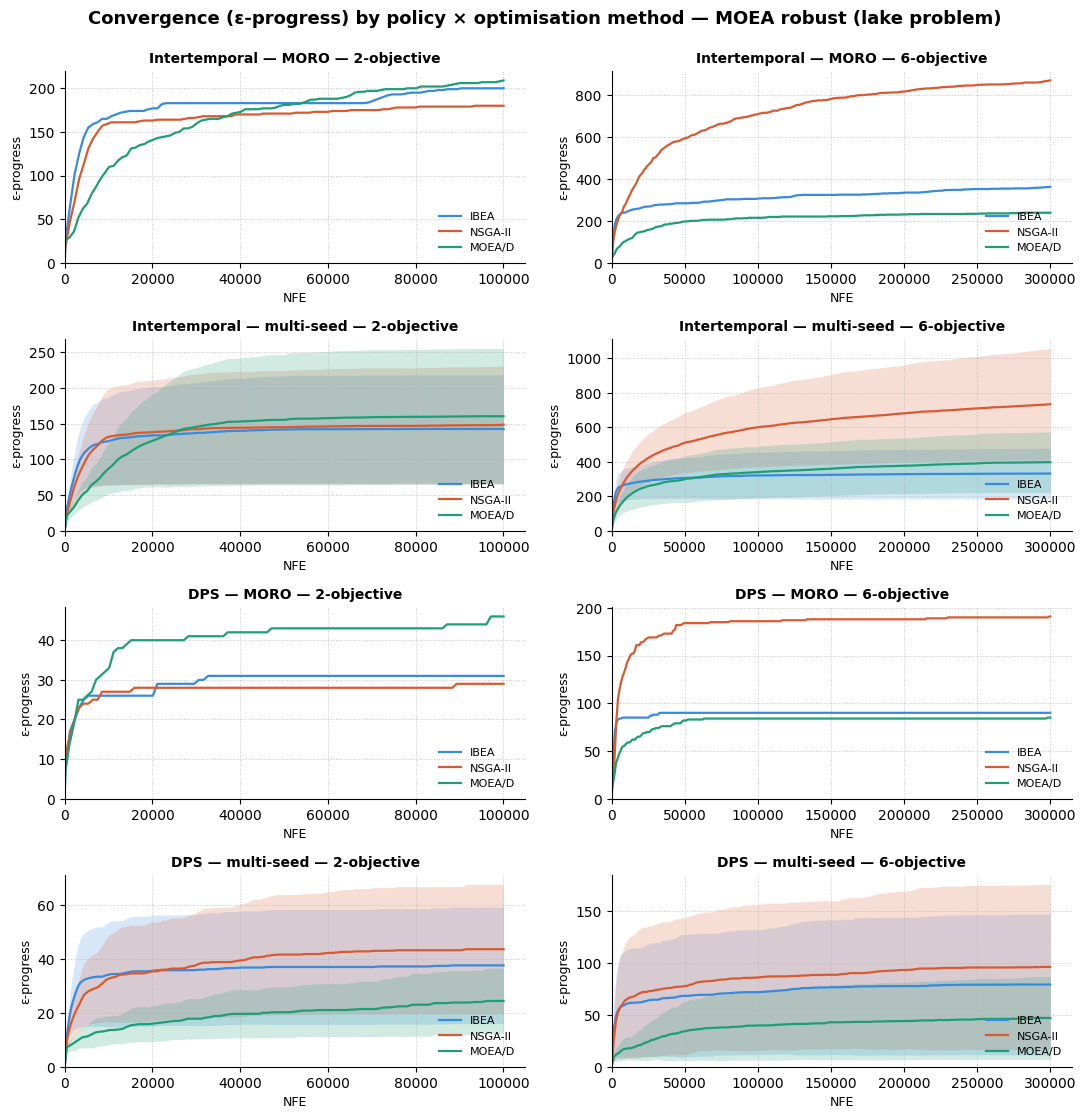

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

COND_LABEL = {
    "intertemporal_moro":  "Intertemporal — MORO",
    "intertemporal_multi": "Intertemporal — Multi",
    "dps_moro":            "DPS — MORO",
    "dps_multi":           "DPS — Multi",
}

ALGOS      = ["IBEA", "NSGAII", "MOEAD"]
CONDITIONS = ["intertemporal_moro", "intertemporal_multi",
              "dps_moro",           "dps_multi"]
N_OBJS     = [2, 6]

FOLDER_RE = re.compile(
    r'^(dps|intertemporal)_(NSGAII|IBEA|MOEAD)_(moro|multi)_(\d+)$'
)


def _convergence_csvs(folder_path):
    files = os.listdir(folder_path)
    return sorted(f for f in files
                  if f.startswith('convergences_') and f.endswith('.csv'))


def load_convergences(base):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        policy, algo, method, n_obj = m.groups()
        n_obj = int(n_obj)
        condition = f"{policy}_{method}"
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csv_names = _convergence_csvs(folder_path)
        if not csv_names:
            continue

        multi_seeded = len(csv_names) > 1
        for idx, csv_name in enumerate(csv_names):
            df = pd.read_csv(os.path.join(folder_path, csv_name))
            if 'nfe' not in df.columns or 'epsilon_progress' not in df.columns:
                continue
            records.append({
                'condition': condition,
                'algo': algo,
                'n_obj': n_obj,
                'seed': idx if multi_seeded else None,
                'df': df[['nfe', 'epsilon_progress']].copy(),
            })
    return records


def aggregate_curves(records, condition, algo, n_obj, common_grid=None):
    matching = [r for r in records
                if r['condition'] == condition
                and r['algo'] == algo
                and r['n_obj'] == n_obj]
    if not matching:
        return None, None, None

    if len(matching) == 1:
        df = matching[0]['df']
        return df['nfe'].values, df['epsilon_progress'].values, np.zeros(len(df))

    if common_grid is None:
        max_nfe = max(r['df']['nfe'].max() for r in matching)
        common_grid = np.linspace(0, max_nfe, 200)

    interpolated = []
    for r in matching:
        df = r['df']
        y = np.interp(common_grid, df['nfe'].values, df['epsilon_progress'].values)
        interpolated.append(y)
    arr = np.array(interpolated)
    return common_grid, arr.mean(axis=0), arr.std(axis=0)


def plot_convergence_panel(ax, records, condition, n_obj, title):
    has_data = False
    for algo in ALGOS:
        grid, mean, std = aggregate_curves(records, condition, algo, n_obj)
        if grid is None:
            continue
        has_data = True
        color = ALGO_COLORS[algo]
        ax.plot(grid, mean, color=color, linewidth=1.6,
                label=ALGO_LABELS[algo])
        if (std > 0).any():
            ax.fill_between(grid, mean - std, mean + std,
                            color=color, alpha=0.2, linewidth=0)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('NFE', fontsize=9)
    ax.set_ylabel('ε-progress', fontsize=9)
    ax.grid(linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    if has_data:
        ax.legend(fontsize=8, loc='lower right', frameon=False)


if __name__ == '__main__':
    BASE = './lake_data/moea_robust'
    OUT = './lake_figures'
    os.makedirs(OUT, exist_ok=True)

    records = load_convergences(BASE)
    if not records:
        raise SystemExit(f'No convergence data found under {BASE}')

    n_cells = len({(r['condition'], r['algo'], r['n_obj']) for r in records})
    print(f'Loaded {len(records)} convergence curve(s) across {n_cells} cells')
    has_seed = any(r['seed'] is not None for r in records)
    if has_seed:
        from collections import Counter
        curves_per_cell = Counter(
            (r['condition'], r['algo'], r['n_obj']) for r in records
        )
        print(f'Curves per cell: min={min(curves_per_cell.values())}, '
              f'max={max(curves_per_cell.values())}')
        moro_cells   = sum(1 for k in curves_per_cell if k[0].endswith('_moro'))
        multi_cells  = sum(1 for k in curves_per_cell if k[0].endswith('_multi'))
        print(f'  MORO cells (single curve): {moro_cells}')
        print(f'  Multi cells (band):   {multi_cells}')

    fig, axes = plt.subplots(
        len(CONDITIONS), len(N_OBJS),
        figsize=(11, 2.8 * len(CONDITIONS)),
        sharex=False,
    )
    fig.suptitle(
        'Convergence (ε-progress) by policy × optimisation method — MOEA robust (lake problem)',
        fontsize=13, fontweight='bold', y=0.995,
    )

    for i, cond in enumerate(CONDITIONS):
        for j, n_obj in enumerate(N_OBJS):
            ax = axes[i, j]
            title = f'{COND_LABEL[cond]} — {n_obj}-objective'
            plot_convergence_panel(ax, records, cond, n_obj, title)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'convergence_epsilon_progress_lake_robust.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

## Robustness (MORL)

Loaded 12 evaluated archive(s) across 12 cells
Cells (algo, method, n_obj):
  decomposition  moro   n_obj=2  pts=  13  hv=  3.3657  runtime=  540s
  decomposition  moro   n_obj=6  pts= 318  hv= 35.0353  runtime= 7457s
  decomposition  multi  n_obj=2  pts=  37  hv=  3.6917  runtime= 1342s
  decomposition  multi  n_obj=6  pts=1431  hv= 27.8176  runtime=20825s
  indicator      moro   n_obj=2  pts=  10  hv=  3.4290  runtime=  743s
  indicator      moro   n_obj=6  pts= 358  hv= 32.0821  runtime=12260s
  indicator      multi  n_obj=2  pts=  29  hv=  3.6843  runtime= 1254s
  indicator      multi  n_obj=6  pts=1547  hv= 30.8895  runtime=42949s
  pareto         moro   n_obj=2  pts=  23  hv=  3.3050  runtime=  800s
  pareto         moro   n_obj=6  pts= 349  hv= 31.1909  runtime=11006s
  pareto         multi  n_obj=2  pts=  64  hv=  3.8615  runtime= 1259s
  pareto         multi  n_obj=6  pts=1403  hv= 34.6575  runtime=32656s
Saved ./lake_figures/hv_morl_lake_robust.png
Saved ./lake_figures/archiv

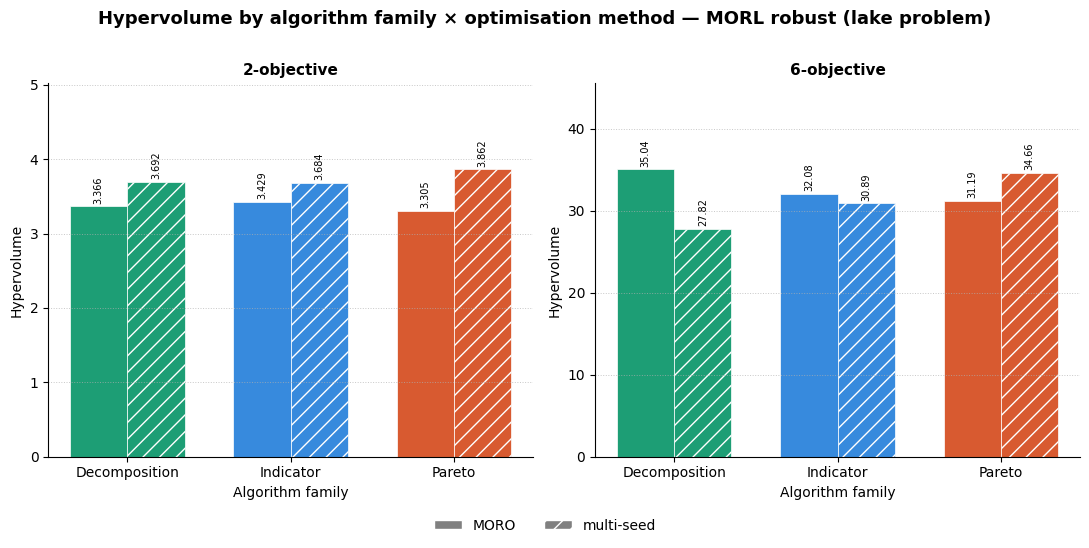

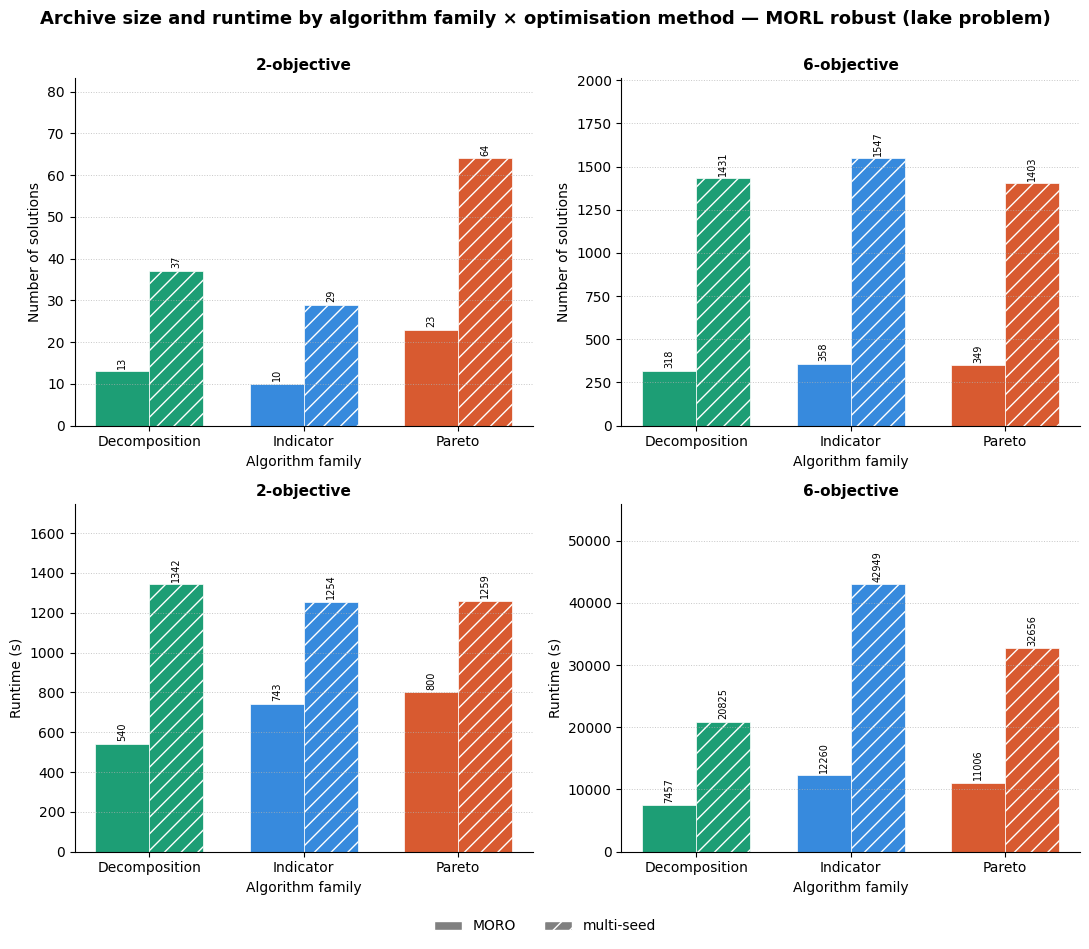

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

ALGO_LABELS = {
    "decomposition": "Decomposition",
    "indicator":     "Indicator",
    "pareto":        "Pareto",
}
ALGO_COLORS = {
    "decomposition": "#1D9E75",
    "indicator":     "#378ADD",
    "pareto":        "#D85A30",
}

COND_LABEL = {"moro": "MORO", "multi": "Multi"}
COND_ALPHA = {"moro": 1.0,    "multi": 1.0}
COND_HATCH = {"moro": "",     "multi": "//"}

ALGOS      = ["decomposition", "indicator", "pareto"]
CONDITIONS = ["moro", "multi"]
N_OBJS     = [2, 6]

FOLDER_RE = re.compile(
    r'^(decomposition|indicator|pareto)_(moro|multi)_(\d+)$'
)

OBJ_COL_RE = re.compile(r'^o\d+(_mean)?$')


def _evaluated_csv(folder_path):
    files = os.listdir(folder_path)
    evaluated = sorted(f for f in files
                       if f.startswith('archives_') and f.endswith('_evaluated.csv'))
    return evaluated[0] if evaluated else None


def _compute_hv(df, ref_value=-1.0):
    obj_cols = [c for c in df.columns if OBJ_COL_RE.match(c)]
    if not obj_cols:
        return None, 0
    vals = np.abs(df[obj_cols].values)
    if len(vals) == 0:
        return 0.0, 0
    ref = np.full(len(obj_cols), ref_value)
    return hypervolume(ref, [tuple(r) for r in vals]), len(vals)


def _parse_runtime_seconds(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergence_') and f.endswith('.csv'))
    if not convs:
        return None

    last_seconds = []
    for c in convs:
        df = pd.read_csv(os.path.join(folder_path, c))
        if 'time' not in df.columns or len(df) == 0:
            continue
        last = str(df['time'].iloc[-1])
        try:
            h, m, s = map(int, last.split(':'))
            last_seconds.append(h * 3600 + m * 60 + s)
        except (ValueError, AttributeError):
            continue

    return max(last_seconds) if last_seconds else None


def load_dataset(base, ref_value=-1.0):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        algo, method, n_obj = m.groups()
        n_obj = int(n_obj)
        condition = method
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csv_name = _evaluated_csv(folder_path)
        if csv_name is None:
            print(f'WARNING: no *_evaluated.csv in {folder_path}, skipping')
            continue

        df = pd.read_csv(os.path.join(folder_path, csv_name))
        hv, n_points = _compute_hv(df, ref_value=ref_value)
        if hv is None:
            print(f'WARNING: no objective columns in {csv_name}, skipping')
            continue

        runtime_s = _parse_runtime_seconds(folder_path)
        records.append({
            'condition': condition, 'algo': algo, 'method': method,
            'n_obj': n_obj,
            'hv': hv, 'n_points': n_points,
            'runtime_s': runtime_s,
        })
    return pd.DataFrame(records)


def aggregate(df):
    grouped = df.groupby(['condition', 'algo', 'n_obj']).agg(
        hv_mean=('hv', 'mean'),
        hv_std=('hv', 'std'),
        n_seeds=('hv', 'count'),
        n_points_mean=('n_points', 'mean'),
        n_points_std=('n_points', 'std'),
        runtime_mean=('runtime_s', 'mean'),
        runtime_std=('runtime_s', 'std'),
    ).reset_index()
    grouped['hv_std'] = grouped['hv_std'].fillna(0.0)
    grouped['n_points_std'] = grouped['n_points_std'].fillna(0.0)
    grouped['runtime_std'] = grouped['runtime_std'].fillna(0.0)
    return grouped


def plot_bars(ax, agg, n_obj, title, metric='hv'):
    subset = agg[agg['n_obj'] == n_obj]
    x = np.arange(len(ALGOS))
    width = 0.35
    n_cond = len(CONDITIONS)
    offsets = (np.arange(n_cond) - (n_cond - 1) / 2.0) * width

    has_variance = (subset['n_seeds'] > 1).any()

    if metric == 'hv':
        mean_col, std_col, ylabel = 'hv_mean', 'hv_std', 'Hypervolume'
        label_fmt = lambda v: f'{v:#.4g}'
    elif metric == 'n_points':
        mean_col, std_col, ylabel = 'n_points_mean', 'n_points_std', 'Number of solutions'
        label_fmt = lambda v: f'{v:.0f}'
    elif metric == 'runtime':
        mean_col, std_col, ylabel = 'runtime_mean', 'runtime_std', 'Runtime (s)'
        label_fmt = lambda v: f'{v:.0f}'
    else:
        raise ValueError(
            f"metric must be 'hv', 'n_points', or 'runtime'; got {metric!r}"
        )

    for offset, cond in zip(offsets, CONDITIONS):
        means, stds = [], []
        for algo in ALGOS:
            row = subset[(subset['algo'] == algo) & (subset['condition'] == cond)]
            if len(row) == 0:
                means.append(0.0)
                stds.append(0.0)
            else:
                means.append(float(row[mean_col].iloc[0]))
                stds.append(float(row[std_col].iloc[0]))

        bars = ax.bar(
            x + offset, means, width=width,
            yerr=stds if has_variance else None,
            capsize=3 if has_variance else 0,
            label=COND_LABEL[cond],
            color=[ALGO_COLORS[a] for a in ALGOS],
            alpha=COND_ALPHA[cond],
            edgecolor='white', linewidth=0.5,
            hatch=COND_HATCH[cond],
            error_kw={'ecolor': '0.3', 'linewidth': 0.8} if has_variance else {},
        )
        ax.bar_label(
            bars,
            labels=[label_fmt(v) for v in means],
            padding=2, fontsize=7, rotation=90,
        )

    max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
    ax.set_ylim(0, max_val * 1.30)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm family', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


def _build_legend_handles():
    return [
        Patch(facecolor='grey', alpha=COND_ALPHA[c], hatch=COND_HATCH[c],
              edgecolor='white', label=COND_LABEL[c])
        for c in CONDITIONS
    ]


if __name__ == '__main__':
    BASE = './lake_data/morl_robust'
    OUT = './lake_figures'
    REF_VALUE = -1.0

    os.makedirs(OUT, exist_ok=True)

    raw = load_dataset(BASE, ref_value=REF_VALUE)
    if raw.empty:
        raise SystemExit(f'No data found under {BASE}')

    n_cells = len(raw[['condition', 'algo', 'n_obj']].drop_duplicates())
    print(f'Loaded {len(raw)} evaluated archive(s) across {n_cells} cells')
    print('Cells (algo, method, n_obj):')
    for _, r in raw[['algo', 'method', 'n_obj', 'n_points', 'hv',
                     'runtime_s']].iterrows():
        rt = f'{r.runtime_s:>5d}s' if r.runtime_s is not None else '    ?'
        print(f'  {r.algo:<14s} {r.method:<6s} n_obj={r.n_obj}  '
              f'pts={r.n_points:>4d}  hv={r.hv:8.4f}  runtime={rt}')

    agg = aggregate(raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle(
        'Hypervolume by algorithm family × optimisation method — MORL robust (lake problem)',
        fontsize=13, fontweight='bold', y=1.01,
    )

    plot_bars(ax1, agg, n_obj=2, title='2-objective', metric='hv')
    plot_bars(ax2, agg, n_obj=6, title='6-objective', metric='hv')

    fig.legend(
        handles=_build_legend_handles(),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=10,
    )
    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_morl_lake_robust.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

    fig2, axes = plt.subplots(2, 2, figsize=(11, 9))
    fig2.suptitle(
        'Archive size and runtime by algorithm family × optimisation method — MORL robust (lake problem)',
        fontsize=13, fontweight='bold', y=1.00,
    )

    plot_bars(axes[0, 0], agg, n_obj=2, title='2-objective', metric='n_points')
    plot_bars(axes[0, 1], agg, n_obj=6, title='6-objective', metric='n_points')
    plot_bars(axes[1, 0], agg, n_obj=2, title='2-objective', metric='runtime')
    plot_bars(axes[1, 1], agg, n_obj=6, title='6-objective', metric='runtime')

    fig2.legend(
        handles=_build_legend_handles(),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10,
    )
    fig2.tight_layout()
    out_path2 = os.path.join(OUT, 'archive_size_and_runtime_morl_lake_robust.png')
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path2}')

Loaded 36 convergence curve(s) across 12 cells
Curves per cell: min=1, max=5
  MORO cells (single curve): 6
  multi-seed cells (band):   6
Saved ./lake_figures/convergence_pcs_size_morl_lake_robust.png


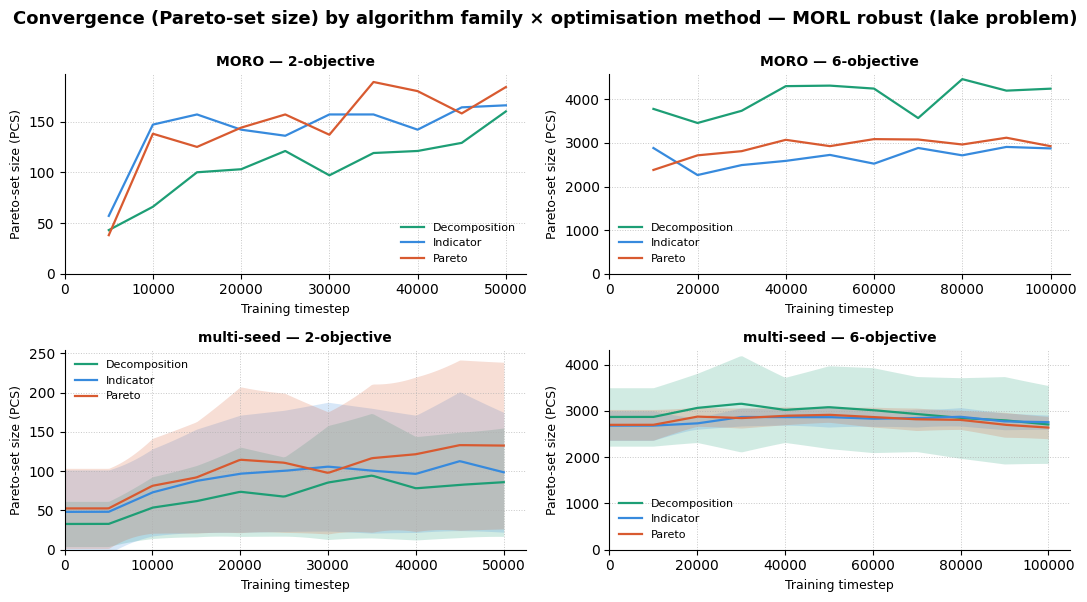

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALGO_LABELS = {
    "decomposition": "Decomposition",
    "indicator":     "Indicator",
    "pareto":        "Pareto",
}
ALGO_COLORS = {
    "decomposition": "#1D9E75",
    "indicator":     "#378ADD",
    "pareto":        "#D85A30",
}

COND_LABEL = {"moro": "MORO", "multi": "Multi"}

ALGOS      = ["decomposition", "indicator", "pareto"]
CONDITIONS = ["moro", "multi"]
N_OBJS     = [2, 6]

FOLDER_RE = re.compile(
    r'^(decomposition|indicator|pareto)_(moro|multi)_(\d+)$'
)

X_COL = 'timestep'
Y_COL = 'pcs_size'


def _convergence_csvs(folder_path):
    files = os.listdir(folder_path)
    return sorted(f for f in files
                  if f.startswith('convergence_') and f.endswith('.csv'))


def load_convergences(base):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        algo, method, n_obj = m.groups()
        n_obj = int(n_obj)
        condition = method
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csv_names = _convergence_csvs(folder_path)
        if not csv_names:
            continue

        multi_seeded = len(csv_names) > 1
        for idx, csv_name in enumerate(csv_names):
            df = pd.read_csv(os.path.join(folder_path, csv_name))
            if X_COL not in df.columns or Y_COL not in df.columns:
                continue
            records.append({
                'condition': condition,
                'algo': algo,
                'n_obj': n_obj,
                'seed': idx if multi_seeded else None,
                'df': df[[X_COL, Y_COL]].copy(),
            })
    return records


def aggregate_curves(records, condition, algo, n_obj, common_grid=None):
    matching = [r for r in records
                if r['condition'] == condition
                and r['algo'] == algo
                and r['n_obj'] == n_obj]
    if not matching:
        return None, None, None

    if len(matching) == 1:
        df = matching[0]['df']
        return df[X_COL].values, df[Y_COL].values.astype(float), np.zeros(len(df))

    if common_grid is None:
        max_x = max(r['df'][X_COL].max() for r in matching)
        common_grid = np.linspace(0, max_x, 200)

    interpolated = []
    for r in matching:
        df = r['df']
        y = np.interp(common_grid, df[X_COL].values, df[Y_COL].values)
        interpolated.append(y)
    arr = np.array(interpolated)
    return common_grid, arr.mean(axis=0), arr.std(axis=0)


def plot_convergence_panel(ax, records, condition, n_obj, title):
    has_data = False
    for algo in ALGOS:
        grid, mean, std = aggregate_curves(records, condition, algo, n_obj)
        if grid is None:
            continue
        has_data = True
        color = ALGO_COLORS[algo]
        ax.plot(grid, mean, color=color, linewidth=1.6,
                label=ALGO_LABELS[algo])
        if (std > 0).any():
            ax.fill_between(grid, mean - std, mean + std,
                            color=color, alpha=0.2, linewidth=0)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Training timestep', fontsize=9)
    ax.set_ylabel('Pareto-set size (PCS)', fontsize=9)
    ax.grid(linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    if has_data:
        ax.legend(fontsize=8, loc='best', frameon=False)


if __name__ == '__main__':
    BASE = './lake_data/morl_robust'
    OUT = './lake_figures'
    os.makedirs(OUT, exist_ok=True)

    records = load_convergences(BASE)
    if not records:
        raise SystemExit(f'No convergence data found under {BASE}')

    n_cells = len({(r['condition'], r['algo'], r['n_obj']) for r in records})
    print(f'Loaded {len(records)} convergence curve(s) across {n_cells} cells')
    has_seed = any(r['seed'] is not None for r in records)
    if has_seed:
        from collections import Counter
        curves_per_cell = Counter(
            (r['condition'], r['algo'], r['n_obj']) for r in records
        )
        print(f'Curves per cell: min={min(curves_per_cell.values())}, '
              f'max={max(curves_per_cell.values())}')
        moro_cells   = sum(1 for k in curves_per_cell if k[0] == 'moro')
        multi_cells  = sum(1 for k in curves_per_cell if k[0] == 'multi')
        print(f'  MORO cells (single curve): {moro_cells}')
        print(f'  Multi cells (band):   {multi_cells}')

    fig, axes = plt.subplots(
        len(CONDITIONS), len(N_OBJS),
        figsize=(11, 3.0 * len(CONDITIONS)),
        sharex=False,
    )
    fig.suptitle(
        'Convergence (Pareto-set size) by algorithm family × optimisation method — MORL robust (lake problem)',
        fontsize=13, fontweight='bold', y=0.995,
    )

    for i, cond in enumerate(CONDITIONS):
        for j, n_obj in enumerate(N_OBJS):
            ax = axes[i, j]
            title = f'{COND_LABEL[cond]} — {n_obj}-objective'
            plot_convergence_panel(ax, records, cond, n_obj, title)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'convergence_pcs_size_morl_lake_robust.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')